# Kakao Deepdive


In [67]:
import os
from google.cloud import bigquery
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.patches as mpatches
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

In [68]:
client = bigquery.Client(project="moloco-ods")

def run_query(query, label=''):
    df = client.query(query).result().to_dataframe()
    print(f'\u2705 {label}: {len(df)} rows')
    return df

CHART_DIR = os.getcwd()  # charts saved alongside notebook

## Section 0 — Parameters

In [69]:
# Reach analysis: longer window for stability
REACH_DATE_START = '2026-03-28'   # TODO: adjust
REACH_DATE_END   = '2026-03-29'

# Postback / assist analysis: shorter window (join is expensive)
ASSIST_DATE_START = '2026-03-21'  # TODO: adjust
ASSIST_DATE_END   = '2026-03-28'

TARGET_COUNTRY = 'KOR'
OFFICE         = 'KOR'

# KakaoTalk publisher bundles (Android + iOS)
KAKAO_BUNDLES = ['com.kakao.talk', '362057947']
KAKAO_BUNDLE_SQL = ", ".join(f"'{b}'" for b in KAKAO_BUNDLES)

# Assist time windows (hours)
ASSIST_WINDOWS_H = [1, 3]   # 6/24/48h dropped — range join is expensive; 1h/3h sufficient

## Section 1-A — Total Device ID Volume: KakaoTalk vs. All Publishers


In [70]:
# coredited_bid is native BQ (faster than slimbidlog external table) — same schema, same data.
# Build a UNION ALL across each day in the reach window instead.

from datetime import date, timedelta

def date_range(start, end):
    d = date.fromisoformat(start)
    end_d = date.fromisoformat(end)
    while d <= end_d:
        yield d.strftime('%Y%m%d')
        d += timedelta(days=1)

def build_slimbidlog_union(date_start, date_end, country, region_filter="'us', 'eu', 'asia'"):
    # Verified field names for codered_bid (inspected 2026-03-30):
    #   country  -> req.device.geo.country  (nested under req)
    #   exchange -> exchange                (top-level flat)
    #   OS       -> req.device.os           (nested under req.device)
    #   bundle   -> app_bundle              (top-level flat)
    #   IDFA     -> req.device.ifa          (nested; no i:/a: prefix unlike slimbidlog)
    tables = [
        f"""  SELECT
    CASE
      WHEN UPPER(req.device.os) LIKE '%IOS%'     THEN 'IOS'
      WHEN UPPER(req.device.os) = 'ANDROID'      THEN 'ANDROID'
    END                               AS os,
    app_bundle,
    req.device.ifa                    AS device_id
  FROM `moloco-dsp-profile-prod.bidlog.codered_bid_{d}`
  WHERE region IN ({region_filter})
    AND req.device.geo.country = '{country}'
    AND UPPER(req.device.os) IN ('IOS', 'ANDROID', 'APPLE IOS')
    AND req.device.ifa IS NOT NULL
    AND req.device.ifa != ''
    AND `moloco-ods.general_utils.is_userid_truly_available`(req.device.ifa) = TRUE"""
        for d in date_range(date_start, date_end)
    ]
    return "\n  UNION ALL\n".join(tables)

union_sql = build_slimbidlog_union(REACH_DATE_START, REACH_DATE_END, TARGET_COUNTRY)

query_1a = f"""
WITH base AS (
  SELECT os, app_bundle, device_id
  FROM (
{union_sql}
  )
  GROUP BY 1, 2, 3  -- deduplicate same device x bundle across days
),
classified AS (
  SELECT
    os,
    device_id,
    MAX(CASE WHEN app_bundle IN ({KAKAO_BUNDLE_SQL}) THEN 1 ELSE 0 END)     AS seen_on_kakao,
    MAX(CASE WHEN app_bundle NOT IN ({KAKAO_BUNDLE_SQL}) THEN 1 ELSE 0 END) AS seen_on_other
  FROM base
  WHERE os IS NOT NULL
  GROUP BY 1, 2
)
SELECT
  os,
  COUNTIF(seen_on_kakao = 1 AND seen_on_other = 0)  AS kakao_exclusive,
  COUNTIF(seen_on_kakao = 1 AND seen_on_other = 1)  AS overlap,
  COUNTIF(seen_on_kakao = 0 AND seen_on_other = 1)  AS non_kakao_only,
  COUNT(*)                                           AS total_device_ids,
  COUNTIF(seen_on_kakao = 1)                         AS total_kakao_device_ids
FROM classified
GROUP BY 1
ORDER BY 1
""".format(KAKAO_BUNDLE_SQL=KAKAO_BUNDLE_SQL)

df_1a = run_query(query_1a, label='1-A device ID volume by publisher type x OS')
df_1a.head()

✅ 1-A device ID volume by publisher type x OS: 2 rows


,os,kakao_exclusive,overlap,non_kakao_only,total_device_ids,total_kakao_device_ids
0,ANDROID,2508836,12407482,13565791,28482109,14916318
1,IOS,1193758,2744396,6385980,10324134,3938154


## Section 1-B — Exclusive Reach Classification (KakaoTalk-only / Both / Non-Kakao)

For each device ID seen in the period, classify into three mutually exclusive groups:
- **KakaoTalk-exclusive** — only appeared in KakaoTalk inventory
- **Overlap** — appeared in both KakaoTalk and other publishers
- **Non-Kakao only** — never appeared in KakaoTalk inventory

Results from 1-A feed directly into this section.

In [71]:
# Section 1-B: compute rates + print classification summary
df_1a['exclusive_reach_rate'] = df_1a['kakao_exclusive'] / df_1a['total_kakao_device_ids']
df_1a['kakao_id_share']       = df_1a['total_kakao_device_ids'] / df_1a['total_device_ids']
df_1a['overlap_rate']         = df_1a['overlap'] / df_1a['total_kakao_device_ids']

print("=== KakaoTalk Exclusive Reach — KOR (sampled; multiply by 10,000 for true vol) ===")
print(df_1a[['os', 'kakao_exclusive', 'overlap', 'non_kakao_only',
             'total_device_ids', 'total_kakao_device_ids',
             'exclusive_reach_rate', 'kakao_id_share']].to_string(index=False))

=== KakaoTalk Exclusive Reach — KOR (sampled; multiply by 10,000 for true vol) ===
     os  kakao_exclusive  overlap  non_kakao_only  total_device_ids  total_kakao_device_ids  exclusive_reach_rate  kakao_id_share
ANDROID          2508836 12407482        13565791          28482109                14916318              0.168194        0.523708
    IOS          1193758  2744396         6385980          10324134                 3938154              0.303126        0.381451


## Section 1-C — Exclusive Reach Rate by OS

Bar chart: `exclusive_reach_rate` and `kakao_id_share` side by side per OS.
Android = primary signal. iOS annotated with ATT caveat.

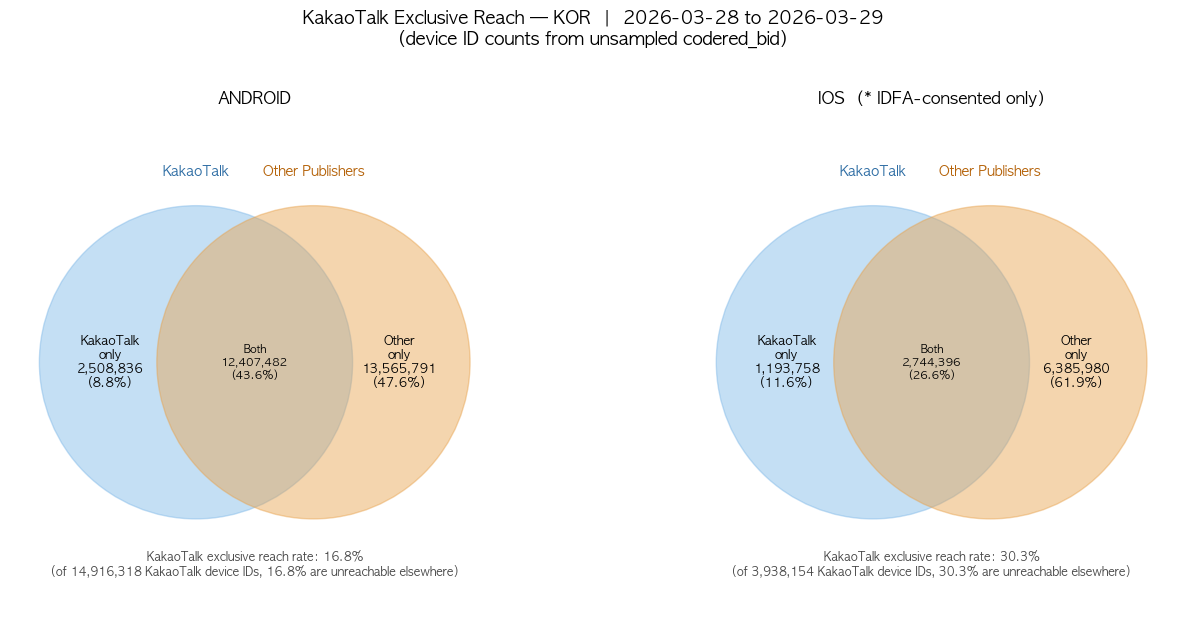

In [72]:
# Section 1-C: Venn diagram — KakaoTalk vs Other Publishers reach, by OS
import matplotlib.patches as patches
from matplotlib.patches import Circle

def draw_venn(ax, exclusive, overlap, non_kakao, os_label):
    total_kakao = exclusive + overlap
    total_other = overlap + non_kakao
    total_all   = exclusive + overlap + non_kakao

    excl_pct    = exclusive / total_all * 100
    overlap_pct = overlap   / total_all * 100
    other_pct   = non_kakao / total_all * 100

    # Draw two overlapping circles
    cx_left, cx_right, cy, r = 0.38, 0.62, 0.5, 0.32
    circle_kt    = Circle((cx_left,  cy), r, color='#7EB8E8', alpha=0.45, zorder=2)
    circle_other = Circle((cx_right, cy), r, color='#E8A24C', alpha=0.45, zorder=2)
    ax.add_patch(circle_kt)
    ax.add_patch(circle_other)

    # Labels inside regions
    ax.text(cx_left - r*0.55, cy,
            f"KakaoTalk\nonly\n{exclusive:,.0f}\n({excl_pct:.1f}%)",
            ha='center', va='center', fontsize=9, fontweight='bold', zorder=3)
    ax.text((cx_left + cx_right) / 2, cy,
            f"Both\n{overlap:,.0f}\n({overlap_pct:.1f}%)",
            ha='center', va='center', fontsize=8, zorder=3)
    ax.text(cx_right + r*0.55, cy,
            f"Other\nonly\n{non_kakao:,.0f}\n({other_pct:.1f}%)",
            ha='center', va='center', fontsize=9, fontweight='bold', zorder=3)

    # Circle labels above
    ax.text(cx_left,  cy + r + 0.06, 'KakaoTalk', ha='center', fontsize=10,
            color='#2E6DA4', fontweight='bold')
    ax.text(cx_right, cy + r + 0.06, 'Other Publishers', ha='center', fontsize=10,
            color='#B5630A', fontweight='bold')

    # Exclusive reach rate annotation below
    excl_rate = exclusive / total_kakao * 100 if total_kakao > 0 else 0
    ax.text(0.5, 0.06,
            f"KakaoTalk exclusive reach rate: {excl_rate:.1f}%\n"
            f"(of {total_kakao:,.0f} KakaoTalk device IDs, {excl_rate:.1f}% are unreachable elsewhere)",
            ha='center', va='bottom', fontsize=8.5, style='italic',
            color='#444', transform=ax.transAxes)

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_title(f'{os_label}', fontsize=12, fontweight='bold', pad=10)


os_list = df_1a['os'].tolist()
n_os = len(os_list)
fig, axes = plt.subplots(1, n_os, figsize=(7 * n_os, 6))
if n_os == 1:
    axes = [axes]

for ax, os_val in zip(axes, os_list):
    row = df_1a[df_1a['os'] == os_val].iloc[0]
    label = f"{os_val}{'  (* IDFA-consented only)' if os_val == 'IOS' else ''}"
    draw_venn(ax,
              exclusive=row['kakao_exclusive'],
              overlap=row['overlap'],
              non_kakao=row['non_kakao_only'],
              os_label=label)

fig.suptitle(
    f'KakaoTalk Exclusive Reach — KOR  |  {REACH_DATE_START} to {REACH_DATE_END}\n'
    f'(device ID counts from unsampled codered_bid)',
    fontsize=13, y=1.02
)
plt.tight_layout()
plt.savefig(os.path.join(CHART_DIR, 'kakao_venn_reach_by_os.png'), dpi=150, bbox_inches='tight')
plt.show()

## Section 1-D — (Optional) Exclusive Reach by Publisher Sub-bundle within KakaoTalk

Within the KakaoTalk exchange, are there specific publisher app bundles (KakaoTalk vs. KakaoStory vs. others)
that drive the exclusive reach? Useful if KakaoTalk exchange carries multiple apps.

In [73]:
# TODO: query publisher sub-bundle breakdown within exchange = 'KAKAO'
query_1d = """
-- Section 1-D: exclusive reach by publisher sub-bundle within KakaoTalk exchange
-- TODO: implement after 1-A is validated
SELECT
  ...
"""
# df_1d = run_query(query_1d, label='1-D exclusive reach by KakaoTalk sub-bundle')
# df_1d.head()

## Section 2-0 — Target Bundles (Top 5 per Vertical × OS)

Query top 5 KakaoTalk-spend bundles per vertical (gaming / non-gaming) × OS from `fact_dsp_publisher`.
Uses the same `ASSIST_DATE_START/END` period as the rest of Section 2.

In [74]:
TOP_N = 5

query_top_bundles = """
SELECT
  product.app_market_bundle                              AS app_bundle,
  product.is_gaming                                      AS is_gaming,
  UPPER(campaign.os)                                     AS os,
  SUM(gross_spend_usd)                                   AS kakao_spend,
  SUM(installs)                                          AS installs
FROM `moloco-ae-view.athena.fact_dsp_publisher`
WHERE date_utc BETWEEN '{ASSIST_DATE_START}' AND '{ASSIST_DATE_END}'
  AND campaign.country = '{TARGET_COUNTRY}'
  AND advertiser.office = '{OFFICE}'
  AND UPPER(campaign.os) IN ('ANDROID', 'IOS')
  AND product.app_market_bundle IS NOT NULL
  AND publisher.app_market_bundle IN ({KAKAO_BUNDLE_SQL})
  AND campaign.type = 'APP_USER_ACQUISITION'
GROUP BY 1, 2, 3
""".format(
    ASSIST_DATE_START=ASSIST_DATE_START,
    ASSIST_DATE_END=ASSIST_DATE_END,
    TARGET_COUNTRY=TARGET_COUNTRY,
    OFFICE=OFFICE,
    KAKAO_BUNDLE_SQL=KAKAO_BUNDLE_SQL,
)

df_bundles = run_query(query_top_bundles, label='2-0 KakaoTalk bundle spend')

# Rank top N per vertical x OS in Python (avoids window function on pre-aggregated view)
df_bundles = df_bundles[df_bundles['kakao_spend'] > 0].copy()
df_bundles['rank_in_group'] = (
    df_bundles.groupby(['is_gaming', 'os'])['kakao_spend']
    .rank(ascending=False, method='first')
)
df_top5 = df_bundles[df_bundles['rank_in_group'] <= TOP_N].copy()

# Look up app names
bundles_sql = ', '.join(f"'{b}'" for b in df_top5['app_bundle'].unique())
df_names = run_query(f"""
SELECT Product_App_Store_Bundle AS bundle, MAX(Product_Title) AS bundle_name
FROM `moloco-ods.business_intelligence.product_dimensions_SoT`
WHERE Product_App_Store_Bundle IN ({bundles_sql})
   OR CONCAT('id', Product_App_Store_Bundle) IN ({bundles_sql})
GROUP BY 1
""", label='2-0 bundle name lookup')
name_map = dict(zip(df_names['bundle'], df_names['bundle_name']))
name_map.update({f"id{{k}}": v for k, v in name_map.items()})
df_top5['bundle_name'] = df_top5['app_bundle'].map(name_map).fillna(df_top5['app_bundle'])

TARGET_BUNDLES    = df_top5['app_bundle'].unique().tolist()
TARGET_BUNDLE_SQL = ', '.join(f"'{b}'" for b in TARGET_BUNDLES)

print(f"\n{len(TARGET_BUNDLES)} unique bundles selected (top {TOP_N} per vertical×OS):")
print(df_top5.sort_values(['is_gaming','os','rank_in_group'], ascending=[False,True,True])
      [['is_gaming','os','rank_in_group','bundle_name','app_bundle','kakao_spend']].to_string(index=False))

✅ 2-0 KakaoTalk bundle spend: 135 rows
✅ 2-0 bundle name lookup: 20 rows

20 unique bundles selected (top 5 per vertical×OS):
 is_gaming      os  rank_in_group                             bundle_name                   app_bundle     kakao_spend
      True ANDROID            1.0            MapleStoryIdleRPG_Android_KR                 com.nexon.ma 22361.545710168
      True ANDROID            2.0                           Lucky Defense com.percent.aos.luckydefense 15798.824529775
      True ANDROID            3.0        The Seven Deadly Sins Origin_AOS        com.netmarble.nanaori 11557.716175440
      True ANDROID            4.0                                 Coop TD       com.percent.aos.cooptd  8001.640492439
      True ANDROID            5.0                StoneAge Pet World - AOS        com.netmarble.stonkey  3476.635854135
      True     IOS            1.0                MapleStoryIdleRPG_iOS_KR                   6739616715 36266.172061233
      True     IOS            2.0        

## Section 2-A — KakaoTalk Impression Volume (Target Bundles)

Impression summary for target bundles only.
Advertiser's app bundle field in `imp`: `api.product.app.store_id`

> **Note:** `api.product.app.store_id` may be the App Store numeric ID for iOS (e.g. `6737408689`).
> Verify it matches `df_top5['app_bundle']` format — add `'id' + store_id` fallback if needed.

In [75]:
query_2a = f"""
SELECT
  api.product.app.store_id         AS app_bundle,
  DATE(timestamp)                  AS date,
  req.device.os                    AS os,
  api.creative.cr_format           AS cr_format,
  COUNT(*)                         AS impressions,
  COUNT(DISTINCT req.device.ifa)   AS unique_device_ids
FROM `focal-elf-631.prod_stream_view.imp`
WHERE DATE(timestamp) BETWEEN '{ASSIST_DATE_START}' AND '{ASSIST_DATE_END}'
  AND req.exchange = 'KAKAO'
  AND req.app.bundle IN ({KAKAO_BUNDLE_SQL})
  AND api.product.app.store_id IN ({TARGET_BUNDLE_SQL})
  AND req.device.ifa IS NOT NULL AND req.device.ifa != ''
GROUP BY 1, 2, 3, 4
ORDER BY 1, 2, 3, 4
""".format(
    ASSIST_DATE_START=ASSIST_DATE_START,
    ASSIST_DATE_END=ASSIST_DATE_END,
    KAKAO_BUNDLE_SQL=KAKAO_BUNDLE_SQL,
    TARGET_BUNDLE_SQL=TARGET_BUNDLE_SQL,
)

df_2a = run_query(query_2a, label='2-A KakaoTalk impression summary — target bundles')
print(f"Total impressions: {{df_2a['impressions'].sum():,}}")
print(f"\nBy app_bundle:")
print(df_2a.groupby('app_bundle')[['impressions','unique_device_ids']].sum().to_string())
df_2a.head(10)

✅ 2-A KakaoTalk impression summary — target bundles: 290 rows
Total impressions: {df_2a['impressions'].sum():,}

By app_bundle:
                              impressions  unique_device_ids
app_bundle                                                  
1148006701                       17109959            4241889
1150231646                       17107063            9295826
1396011926                       12934706            2974564
1445504255                        1626249            1013541
1474589366                       12533235            3997357
1554807824                       13045151            3135022
6482291732                      106749843            6857579
6503702666                       71365129            6664126
6739616715                      115645058            6898061
6744205088                       10831371            2666584
com.ktmusic.geniemusic            6834515            2679649
com.naverfin.payapp              10500854            5642200
com.netmarble.nana

,app_bundle,date,os,cr_format,impressions,unique_device_ids
0,1148006701,2026-03-21,IOS,ib,1432554,459065
1,1148006701,2026-03-22,IOS,ib,1840929,471174
2,1148006701,2026-03-23,IOS,ib,2779881,555651
3,1148006701,2026-03-24,IOS,ib,2945050,607734
4,1148006701,2026-03-25,IOS,ib,3147648,671183
5,1148006701,2026-03-26,IOS,ib,2544639,658410
6,1148006701,2026-03-27,IOS,ib,1161830,394111
7,1148006701,2026-03-28,IOS,ib,1257428,424561
8,1150231646,2026-03-21,IOS,ib,1196977,834678
9,1150231646,2026-03-22,IOS,ib,1685434,1005019


## Section 2-B — Install Events from Postback (Target Bundles)

Pull all install events for the target app bundles from `focal-elf-631.prod_stream_view.pb`.
Installed app bundle field: `app.bundle`
Both Moloco-attributed and non-attributed installs included.
`moloco.attributed` kept as a flag to split last-touch vs assisted in 2-D/2-E.

In [76]:
# 2-B: aggregated coverage check — do NOT pull raw rows (table too large)
# Device-level join with impressions happens entirely in BQ in Section 2-C.

query_2b = f"""
SELECT
  app.bundle                                                          AS app_bundle,
  device.os                                                           AS os,
  COUNT(*)                                                            AS total_installs,
  COUNTIF(`moloco-ods.general_utils.is_userid_truly_available`(device.ifa)) AS ifa_available_installs,
  COUNTIF(moloco.attributed = TRUE)                                   AS moloco_attributed_installs,
  SAFE_DIVIDE(
    COUNTIF(`moloco-ods.general_utils.is_userid_truly_available`(device.ifa)),
    COUNT(*)
  )                                                                   AS ifa_coverage_rate
FROM `focal-elf-631.prod_stream_view.pb`
WHERE DATE(timestamp) BETWEEN '{ASSIST_DATE_START}' AND '{ASSIST_DATE_END}'
  AND app.bundle IN ({TARGET_BUNDLE_SQL})
  AND device.ifa IS NOT NULL AND device.ifa != ''
GROUP BY 1, 2
ORDER BY 1, 2
""".format(
    ASSIST_DATE_START=ASSIST_DATE_START,
    ASSIST_DATE_END=ASSIST_DATE_END,
    TARGET_BUNDLE_SQL=TARGET_BUNDLE_SQL,
)

df_2b = run_query(query_2b, label='2-B install coverage — target bundles')

overall_ifa  = (df_2b['ifa_available_installs'].sum() / df_2b['total_installs'].sum())
overall_attr = (df_2b['moloco_attributed_installs'].sum() / df_2b['total_installs'].sum())
print(f"Total installs: {{df_2b['total_installs'].sum():,}}")
print(f"IFA truly available: {{overall_ifa:.1%}}")
print(f"Moloco-attributed:   {{overall_attr:.1%}}")
print()
print(df_2b.to_string(index=False))

✅ 2-B install coverage — target bundles: 11 rows
Total installs: {df_2b['total_installs'].sum():,}
IFA truly available: {overall_ifa:.1%}
Moloco-attributed:   {overall_attr:.1%}

                  app_bundle      os  total_installs  ifa_available_installs  moloco_attributed_installs  ifa_coverage_rate
                  6739616715     IOS          456762                  456762                      341337           1.000000
      com.ktmusic.geniemusic ANDROID          867030                  800190                      310829           0.922909
         com.naverfin.payapp ANDROID         3588761                 3452244                     3394753           0.961960
       com.netmarble.nanaori ANDROID         2051131                 1987761                      587344           0.969105
       com.netmarble.stonkey ANDROID         1641348                 1622588                     1215951           0.988570
                com.nexon.ma ANDROID          797658                  797658 

## Section 2-C — Range Join: KakaoTalk Impression → Install within X Hours

For each KakaoTalk impression on a target bundle, check if the same device installed that app within `[impression_ts, impression_ts + Xh]`.
Runs for each window in `ASSIST_WINDOWS_H` = `[1, 3]` hours.

In [83]:
# Section 2-C: base = total installs; look back for KakaoTalk impressions within Xh
# Join direction: installs (left) ← kakao impressions (right, within prior Xh)

query_2c_template = """
WITH installs AS (
  SELECT
    app.bundle                 AS app_bundle,
    device.ifa                 AS device_id,
    event.install_at           AS install_ts,
    device.os                  AS os,
    moloco.attributed          AS moloco_attributed
  FROM `focal-elf-631.prod_stream_view.pb`
  WHERE DATE(timestamp) BETWEEN '{ASSIST_DATE_START}' AND '{ASSIST_DATE_END}'
    AND app.bundle IN ({TARGET_BUNDLE_SQL})
    AND device.ifa IS NOT NULL AND device.ifa != ''
    AND `moloco-ods.general_utils.is_userid_truly_available`(device.ifa) = TRUE
),
kakao_imps AS (
  SELECT
    api.product.app.store_id   AS app_bundle,
    req.device.ifa             AS device_id,
    timestamp                  AS impression_ts,
    api.creative.cr_format     AS cr_format
  FROM `focal-elf-631.prod_stream_view.imp`
  WHERE DATE(timestamp) BETWEEN '{ASSIST_DATE_START}' AND '{ASSIST_DATE_END}'
    AND req.exchange = 'KAKAO'
    AND req.app.bundle IN ({KAKAO_BUNDLE_SQL})
    AND api.product.app.store_id IN ({TARGET_BUNDLE_SQL})
    AND req.device.ifa IS NOT NULL AND req.device.ifa != ''
),
joined AS (
  SELECT
    i.app_bundle,
    i.os,
    i.device_id,
    i.moloco_attributed,
    MAX(CASE WHEN k.device_id IS NOT NULL THEN 1 ELSE 0 END)  AS had_kakao_imp
  FROM installs i
  LEFT JOIN kakao_imps k
    ON  i.device_id  = k.device_id
    AND i.app_bundle = k.app_bundle
    AND k.impression_ts BETWEEN TIMESTAMP_SUB(i.install_ts, INTERVAL {window_h} HOUR)
                            AND i.install_ts
  GROUP BY 1, 2, 3, 4
)
SELECT
  app_bundle,
  os,
  COUNT(*)                                                     AS total_installs,
  COUNTIF(had_kakao_imp = 1)                                   AS had_kakao_imp,
  COUNTIF(had_kakao_imp = 1 AND moloco_attributed = TRUE)      AS last_touch,
  COUNTIF(had_kakao_imp = 1 AND (moloco_attributed = FALSE
                                  OR moloco_attributed IS NULL)) AS assisted,
  SAFE_DIVIDE(COUNTIF(had_kakao_imp = 1), COUNT(*))            AS kakao_touch_rate,
  SAFE_DIVIDE(COUNTIF(moloco_attributed = TRUE), COUNT(*))     AS moloco_attr_rate
FROM joined
GROUP BY 1, 2
ORDER BY 1, 2
"""

results_by_window = {}
for w in ASSIST_WINDOWS_H:
    q = query_2c_template.format(
        ASSIST_DATE_START=ASSIST_DATE_START,
        ASSIST_DATE_END=ASSIST_DATE_END,
        KAKAO_BUNDLE_SQL=KAKAO_BUNDLE_SQL,
        TARGET_BUNDLE_SQL=TARGET_BUNDLE_SQL,
        window_h=w,
    )
    results_by_window[w] = run_query(q, label=f'2-C install base → kakao touch {w}h')

print(f"\nRow counts per window: { {w: len(df) for w, df in results_by_window.items()} }")
for w, df in results_by_window.items():
    print(f"\n=== {w}h window ===")
    print(df.to_string(index=False))

✅ 2-C install base → kakao touch 1h: 11 rows
✅ 2-C install base → kakao touch 3h: 11 rows

Row counts per window: {1: 11, 3: 11}

=== 1h window ===
                  app_bundle      os  total_installs  had_kakao_imp  last_touch  assisted  kakao_touch_rate  moloco_attr_rate
                  6739616715     IOS           40401            103          62        41          0.002549          0.478429
      com.ktmusic.geniemusic ANDROID          359997              0           0         0          0.000000          0.060537
         com.naverfin.payapp ANDROID          326409           4191        3227       964          0.012840          0.542807
       com.netmarble.nanaori ANDROID         1016430           8316        3750      4566          0.008182          0.033363
       com.netmarble.stonkey ANDROID          191253            241          81       160          0.001260          0.045981
                com.nexon.ma ANDROID          154961           1396         405       991       

## Section 2-D — Conversion Rate by Window

Of devices exposed to a KakaoTalk ad for a target bundle, what % installed within X hours?
Split by: **last-touch** (Moloco-attributed) vs **assisted** (installed within window, attributed elsewhere).

Charts:
- Overall conversion rate by window (1h / 3h), stacked last-touch vs assisted
- Per-bundle conversion rate heatmap

=== % of total installs with KakaoTalk touch ===
 window_h  total_installs  had_kakao_imp  last_touch  assisted  kakao_touch_rate  last_touch_rate  assisted_rate
        1         8789070          42013       31543     10470          0.004780         0.003589       0.001191
        3         8789070          68337       48795     19542          0.007775         0.005552       0.002223


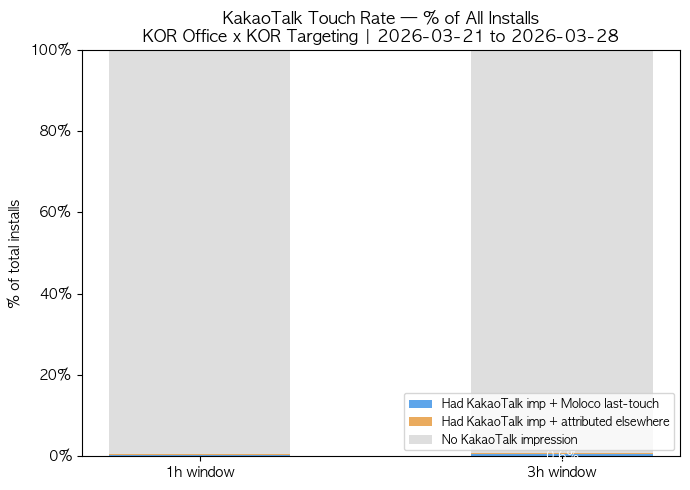

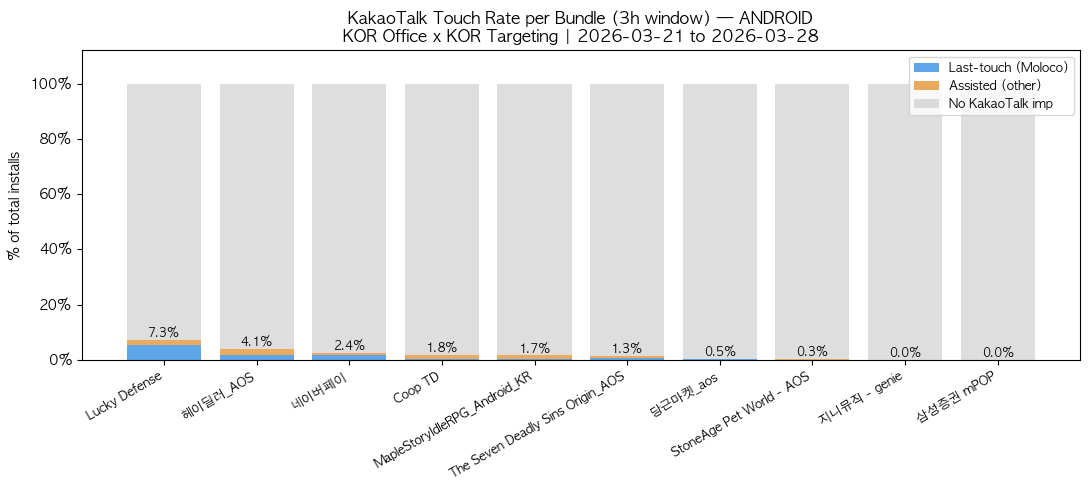

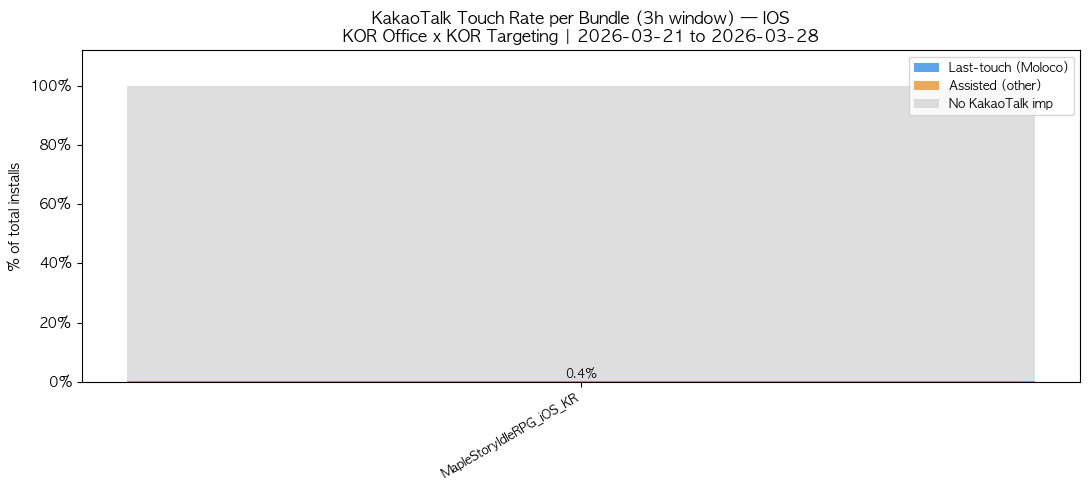

In [84]:
# ── 2-D-1: Summary table ─────────────────────────────────────────────────────
summary_rows = []
for w, df in results_by_window.items():
    total      = df['total_installs'].sum()
    had_kakao  = df['had_kakao_imp'].sum()
    last_touch = df['last_touch'].sum()
    assisted   = df['assisted'].sum()
    summary_rows.append({
        'window_h':       w,
        'total_installs': total,
        'had_kakao_imp':  had_kakao,
        'last_touch':     last_touch,
        'assisted':       assisted,
        'no_kakao':       total - had_kakao,
        'kakao_touch_rate': had_kakao  / total if total else 0,
        'last_touch_rate':  last_touch / total if total else 0,
        'assisted_rate':    assisted   / total if total else 0,
    })
df_summary = pd.DataFrame(summary_rows)
print("=== % of total installs with KakaoTalk touch ===")
print(df_summary[['window_h', 'total_installs', 'had_kakao_imp', 'last_touch', 'assisted',
                   'kakao_touch_rate', 'last_touch_rate', 'assisted_rate']].to_string(index=False))

# ── 2-D-2: Stacked bar — % of total installs ─────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))
x     = np.arange(len(df_summary))
width = 0.5

b1 = ax.bar(x, df_summary['last_touch_rate'], width,
            label='Had KakaoTalk imp + Moloco last-touch', color='#4C9BE8', alpha=0.9)
b2 = ax.bar(x, df_summary['assisted_rate'], width,
            bottom=df_summary['last_touch_rate'],
            label='Had KakaoTalk imp + attributed elsewhere', color='#E8A24C', alpha=0.9)
b3 = ax.bar(x, 1 - df_summary['kakao_touch_rate'], width,
            bottom=df_summary['kakao_touch_rate'],
            label='No KakaoTalk impression', color='#D0D0D0', alpha=0.7)

for bar, v in zip(b1, df_summary['last_touch_rate']):
    if v > 0.005:
        ax.text(bar.get_x() + bar.get_width() / 2, v / 2, f'{v:.1%}',
                ha='center', va='center', fontsize=9, color='white', fontweight='bold')

for bar, vlt, vas in zip(b2, df_summary['last_touch_rate'], df_summary['assisted_rate']):
    if vas > 0.005:
        ax.text(bar.get_x() + bar.get_width() / 2, vlt + vas / 2, f'{vas:.1%}',
                ha='center', va='center', fontsize=9, color='white', fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels([f'{w}h window' for w in df_summary['window_h']])
ax.yaxis.set_major_formatter(ticker.PercentFormatter(xmax=1))
ax.set_ylim(0, 1)
ax.set_ylabel('% of total installs')
ax.set_title(
    f'KakaoTalk Touch Rate — % of All Installs\n'
    f'KOR Office x KOR Targeting | {ASSIST_DATE_START} to {ASSIST_DATE_END}'
)
ax.legend(loc='lower right', fontsize=8.5)
plt.tight_layout()
plt.savefig(os.path.join(CHART_DIR, 'kakao_touch_rate_of_installs.png'), dpi=150, bbox_inches='tight')
plt.show()

# ── 2-D-3: Per-bundle bar (primary window) ────────────────────────────────────
primary_w  = max(results_by_window.keys())
df_primary = results_by_window[primary_w].copy()
df_primary['bundle_name'] = (
    df_primary['app_bundle']
    .map(df_top5.set_index('app_bundle')['bundle_name'])
    .fillna(df_primary['app_bundle'])
)
df_primary['kakao_touch_rate'] = df_primary['had_kakao_imp'] / df_primary['total_installs']
df_primary['last_touch_rate']  = df_primary['last_touch']    / df_primary['total_installs']
df_primary['assisted_rate']    = df_primary['assisted']      / df_primary['total_installs']

for os_val in ['ANDROID', 'IOS']:
    d = df_primary[df_primary['os'] == os_val].sort_values('kakao_touch_rate', ascending=False)
    if d.empty:
        continue
    fig, ax = plt.subplots(figsize=(11, 5))
    xi = np.arange(len(d))
    ax.bar(xi, d['last_touch_rate'], label='Last-touch (Moloco)', color='#4C9BE8', alpha=0.9)
    ax.bar(xi, d['assisted_rate'],   label='Assisted (other)',    color='#E8A24C', alpha=0.9,
           bottom=d['last_touch_rate'].values)
    ax.bar(xi, 1 - d['kakao_touch_rate'], label='No KakaoTalk imp', color='#D0D0D0', alpha=0.7,
           bottom=d['kakao_touch_rate'].values)
    for x_pos, vkt in zip(xi, d['kakao_touch_rate']):
        ax.text(x_pos, vkt + 0.005, f'{vkt:.1%}',
                ha='center', va='bottom', fontsize=8.5, fontweight='bold')
    ax.set_xticks(xi)
    ax.set_xticklabels(d['bundle_name'], rotation=30, ha='right', fontsize=9)
    ax.yaxis.set_major_formatter(ticker.PercentFormatter(xmax=1))
    ax.set_ylim(0, 1.12)
    ax.set_ylabel('% of total installs')
    ax.set_title(
        f'KakaoTalk Touch Rate per Bundle ({primary_w}h window) — {os_val}\n'
        f'KOR Office x KOR Targeting | {ASSIST_DATE_START} to {ASSIST_DATE_END}'
    )
    ax.legend(fontsize=9, loc='upper right')
    plt.tight_layout()
    plt.savefig(os.path.join(CHART_DIR, f'kakao_touch_rate_by_bundle_{os_val}.png'),
                dpi=150, bbox_inches='tight')
    plt.show()


## Section 2-E — Assist Rate by OS × cr_format × Last-Touch Attribution

For KakaoTalk-assisted installs, break down:
- By OS (Android vs. iOS)
- By `cr_format` of the KakaoTalk impression (ib / nl / ni — view-through skew?)
- By whether the last-touch was also KakaoTalk or a different publisher

Key question: are "pure assists" (KT exposure → install elsewhere) concentrated in a specific format?

In [ ]:
# TODO: implement after 2-C is validated
#
# Use 24h window as primary; annotate 6h and 48h for sensitivity
#
# df_24h = results_by_window[24].copy()
# df_24h['assisted'] = df_24h['kakao_imp_count'] > 0
# df_24h['pure_assist'] = df_24h['assisted'] & ~df_24h['attributed_pub_bundle'].isin(KAKAO_BUNDLES)
# df_24h['last_touch_kakao'] = df_24h['assisted'] & df_24h['attributed_pub_bundle'].isin(KAKAO_BUNDLES)
#
# breakdown = df_24h.groupby(['os', 'kakao_cr_format']).agg(
#     total=('device_id', 'count'),
#     assisted=('assisted', 'sum'),
#     pure_assist=('pure_assist', 'sum'),
#     last_touch_kakao=('last_touch_kakao', 'sum'),
# ).reset_index()
# breakdown['assist_rate'] = breakdown['assisted'] / breakdown['total']
# breakdown['pure_assist_rate'] = breakdown['pure_assist'] / breakdown['total']
# print(breakdown.to_string(index=False))
#
# # Stacked bar: last-touch KakaoTalk vs. pure assist, by OS
# fig, ax = plt.subplots(figsize=(10, 5))
# # ... stacked bar implementation
# plt.savefig(os.path.join(CHART_DIR, 'kakao_assist_breakdown_by_os_format.png'), dpi=150, bbox_inches='tight')
# plt.show()